In [1]:
!pip install kaggle lightgbm -q

In [ ]:
from google.colab import files
files.upload()

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d yasserh/instacart-online-grocery-basket-analysis-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset
License(s): CC0-1.0
100% 197M/197M [00:01<00:00, 120MB/s]



In [5]:
!unzip instacart-online-grocery-basket-analysis-dataset.zip

Archive:  instacart-online-grocery-basket-analysis-dataset.zip
  inflating: aisles.csv              
  inflating: departments.csv         
  inflating: order_products__prior.csv  
  inflating: order_products__train.csv  
  inflating: orders.csv              
  inflating: products.csv            


In [6]:
!ls

aisles.csv					      order_products__train.csv
departments.csv					      orders.csv
instacart-online-grocery-basket-analysis-dataset.zip  products.csv
kaggle.json					      sample_data
order_products__prior.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

orders = pd.read_csv('orders.csv')
order_products_prior = pd.read_csv('order_products__prior.csv')
order_products_train = pd.read_csv('order_products__train.csv')
products = pd.read_csv('products.csv')
aisles = pd.read_csv('aisles.csv')
departments = pd.read_csv('departments.csv')

In [8]:
print('orders:', orders.shape)
print('order_products_prior:', order_products_prior.shape)
print('order_products_train:', order_products_train.shape)
print('products:', products.shape)

orders.head()

orders: (3421083, 7)
order_products_prior: (32434489, 4)
order_products_train: (1384617, 4)
products: (49688, 4)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [9]:
print('Уникальных пользователей:', orders['user_id'].nunique())
print('Уникальных заказов:', orders['order_id'].nunique())
print('Уникальных продуктов:', products['product_id'].nunique())
print('Строк в prior:', order_products_prior.shape[0])

Уникальных пользователей: 206209
Уникальных заказов: 3421083
Уникальных продуктов: 49688
Строк в prior: 32434489


# **EDA: Общий обзор данных**

*   Датасет содержит более 3 млн заказов от более чем 200 000 пользователей
*   Данные разделены на prior (история заказов) и train (последний заказ пользователя)
*   Для построения признаков используется prior — история покупок каждого пользователя

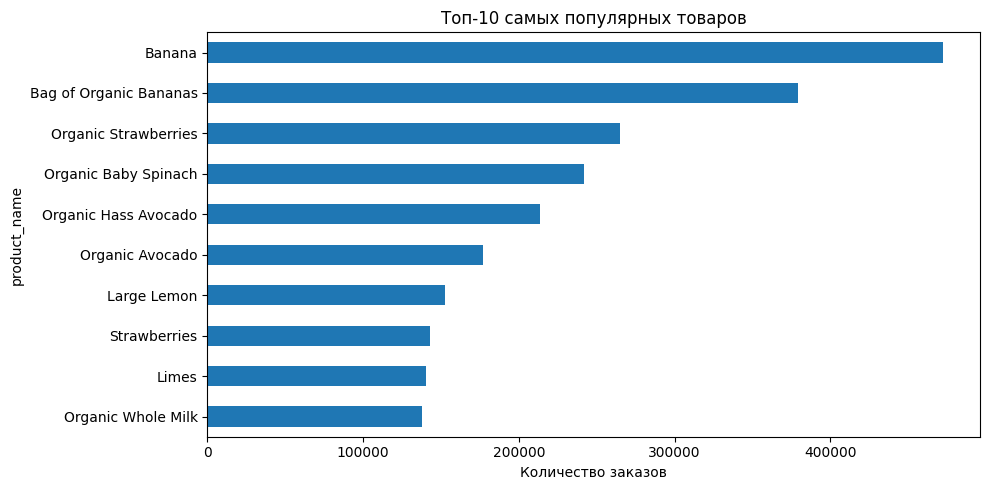

In [10]:
top_products = (
    order_products_prior
    .merge(products, on='product_id')
    .groupby('product_name')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_products.plot(kind='barh')
plt.title('Топ-10 самых популярных товаров')
plt.xlabel('Количество заказов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

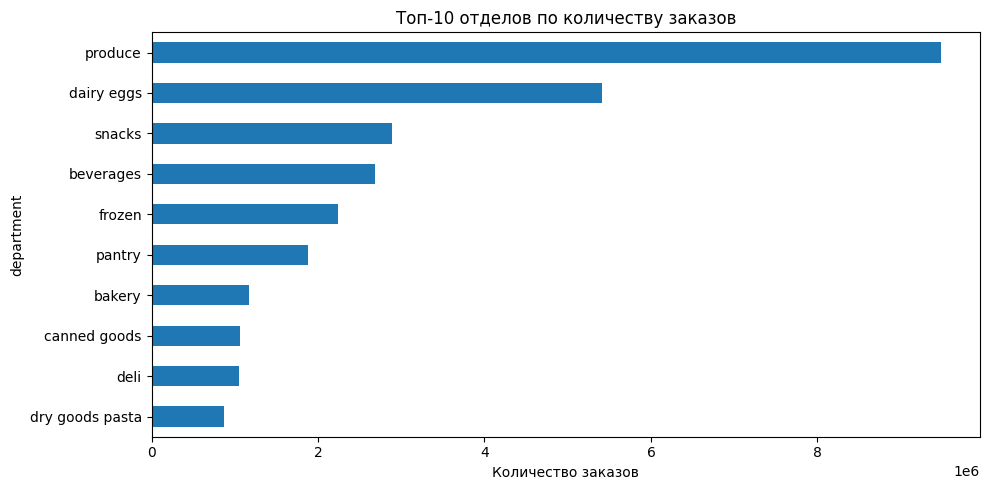

In [11]:
top_departments = (
    order_products_prior
    .merge(products, on='product_id')
    .merge(departments, on='department_id')
    .groupby('department')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_departments.plot(kind='barh')
plt.title('Топ-10 отделов по количеству заказов')
plt.xlabel('Количество заказов')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
prior_orders = orders[orders['eval_set'] == 'prior']

orders_per_user = prior_orders.groupby('user_id')['order_id'].count()
orders_per_user.describe()

,order_id
count,206209.000000
mean,15.590367
std,16.654774
min,3.000000
25%,5.000000
50%,9.000000
75%,19.000000
max,99.000000


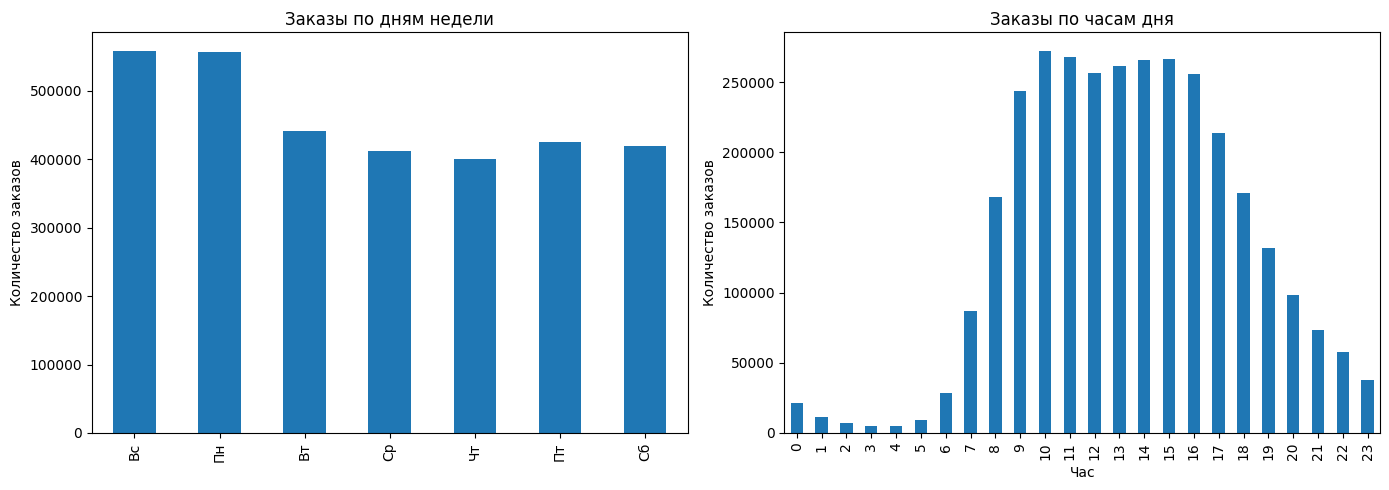

In [13]:
dow_map = {0: 'Вс', 1: 'Пн', 2: 'Вт', 3: 'Ср', 4: 'Чт', 5: 'Пт', 6: 'Сб'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prior_orders['order_dow'].map(dow_map).value_counts().reindex(dow_map.values()).plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Заказы по дням недели')
axes[0].set_xlabel('')
axes[0].set_ylabel('Количество заказов')

prior_orders['order_hour_of_day'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Заказы по часам дня')
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.show()

# **H1: Пользователи чаще всего делают заказы в начале недели и в дневные часы**

*   Пик заказов приходится на воскресенье и понедельник
*   По времени суток максимальная активность с 9 до 16 часов
*   Это важно для планирования маркетинговых кампаний и push-уведомлений

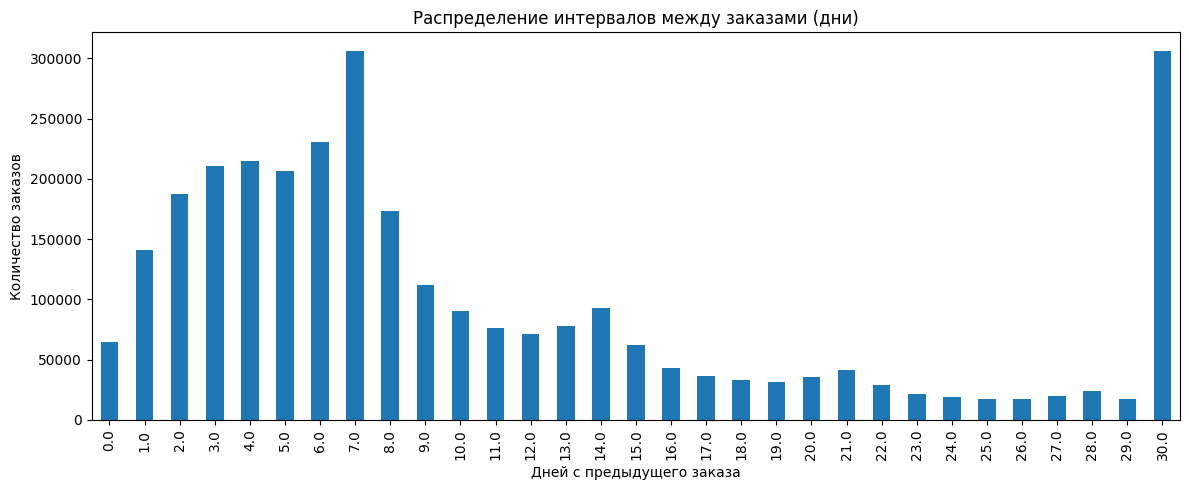

Медиана интервала между заказами: 7.0 дней
Среднее: 10.7 дней


In [14]:
plt.figure(figsize=(12, 5))
prior_orders['days_since_prior_order'].dropna().value_counts().sort_index().plot(kind='bar')
plt.title('Распределение интервалов между заказами (дни)')
plt.xlabel('Дней с предыдущего заказа')
plt.ylabel('Количество заказов')
plt.tight_layout()
plt.show()

print('Медиана интервала между заказами:', prior_orders['days_since_prior_order'].median(), 'дней')
print('Среднее:', round(prior_orders['days_since_prior_order'].mean(), 1), 'дней')

# **H2: Большинство пользователей делают повторный заказ раз в неделю или раз в месяц**

*   Распределение days_since_prior_order имеет выраженные пики на 7 и 30 днях
*   Два основных паттерна: еженедельные и ежемесячные покупки
*   Пользователей с интервалом 7 дней имеет смысл вовлекать через еженедельные напоминания

In [15]:
overall_reorder_rate = order_products_prior['reordered'].mean()
print('Общий reorder rate:', round(overall_reorder_rate, 3))

Общий reorder rate: 0.59


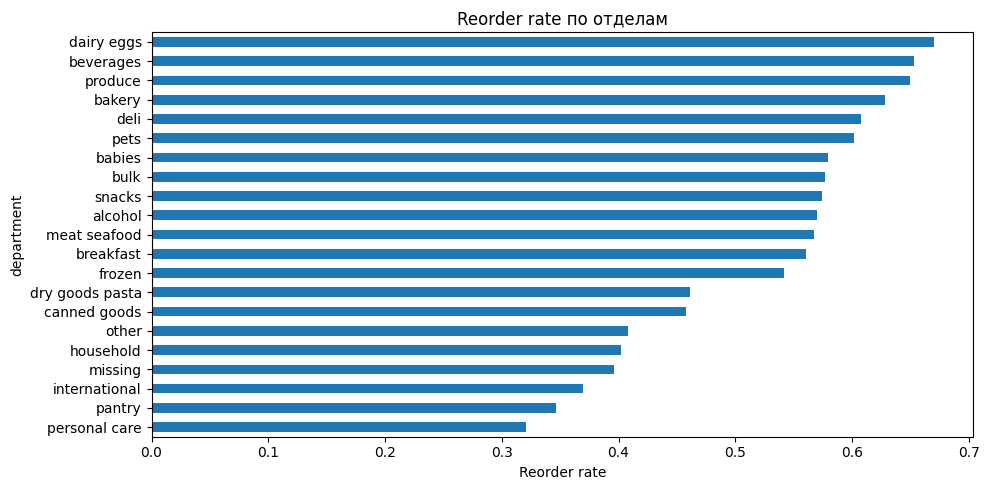

In [16]:
reorder_by_dept = (
    order_products_prior
    .merge(products, on='product_id')
    .merge(departments, on='department_id')
    .groupby('department')['reordered']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
reorder_by_dept.plot(kind='barh')
plt.title('Reorder rate по отделам')
plt.xlabel('Reorder rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **H3: Более половины товаров в заказах — повторные покупки**

*   Общий reorder rate по датасету составляет ~59%
*   Отдел produce (свежие продукты, органика) имеет наибольший reorder rate
*   Отделы с низким reorder rate (personal care, household) — товары редкого спроса
*   Высокий reorder rate означает предсказуемость покупок — хорошая основа для рекомендаций

In [17]:
orders_per_user_df = prior_orders.groupby('user_id')['order_id'].count().reset_index()
orders_per_user_df.columns = ['user_id', 'order_count']

orders_per_user_df['segment'] = pd.qcut(
    orders_per_user_df['order_count'],
    q=3,
    labels=['low', 'medium', 'high']
)

orders_per_user_df['order_count'].describe()

,order_count
count,206209.000000
mean,15.590367
std,16.654774
min,3.000000
25%,5.000000
50%,9.000000
75%,19.000000
max,99.000000


In [18]:
user_reorder = (
    order_products_prior
    .merge(prior_orders[['order_id', 'user_id']], on='order_id')
    .groupby('user_id')['reordered']
    .mean()
    .reset_index()
)
user_reorder.columns = ['user_id', 'user_reorder_rate']

segment_reorder = orders_per_user_df.merge(user_reorder, on='user_id')
segment_reorder.groupby('segment')['user_reorder_rate'].mean().round(3)

,user_reorder_rate
segment,
low,0.262
medium,0.432
high,0.624


# **H4: Более активные пользователи перезаказывают товары чаще**

*   Reorder rate в сегменте high значительно выше, чем в low
*   Активные пользователи имеют более устойчивые предпочтения — их проще моделировать
*   Пользователи с малым числом заказов непредсказуемы, для них нужны другие стратегии

# **H5: Feature Engineering — построение признаков на уровне user-product**

*   Целевая переменная: reordered в последнем заказе пользователя (train set)
*   Признаки строятся из prior-истории — что пользователь покупал до финального заказа
*   Ключевые признаки: сколько раз user купил product, как часто user перезаказывает, насколько product популярен

In [19]:
prior_with_user = order_products_prior.merge(
    orders[orders['eval_set'] == 'prior'][['order_id', 'user_id', 'days_since_prior_order']],
    on='order_id'
)

In [20]:
# Сколько раз user купил данный product
user_product_count = (
    prior_with_user
    .groupby(['user_id', 'product_id'])['order_id']
    .count()
    .reset_index()
)
user_product_count.columns = ['user_id', 'product_id', 'user_product_orders']

# Признаки пользователя
user_features = (
    prior_with_user
    .groupby('user_id')
    .agg(
        user_total_orders=('order_id', 'nunique'),
        user_reorder_rate=('reordered', 'mean'),
        user_avg_days_since=('days_since_prior_order', 'mean')
    )
    .reset_index()
)

# Признаки товара
product_features = (
    prior_with_user
    .groupby('product_id')
    .agg(
        product_orders=('order_id', 'count'),
        product_reorder_rate=('reordered', 'mean'),
        product_unique_users=('user_id', 'nunique')
    )
    .reset_index()
)

print('user_product_count:', user_product_count.shape)
print('user_features:', user_features.shape)
print('product_features:', product_features.shape)

user_product_count: (13307953, 3)
user_features: (206209, 4)
product_features: (49677, 4)


In [21]:
# days_since_last_purchase — сколько заказов назад пользователь последний раз купил товар
# Берём order_number из orders и считаем разницу с последним заказом пользователя

prior_with_order_num = prior_with_user.merge(
    orders[orders['eval_set'] == 'prior'][['order_id', 'user_id', 'order_number']],
    on=['order_id', 'user_id']
)

# Последний номер заказа каждого пользователя
user_last_order_num = (
    prior_with_order_num
    .groupby('user_id')['order_number']
    .max()
    .reset_index()
)
user_last_order_num.columns = ['user_id', 'user_max_order_number']

# Последний заказ, в котором был куплен конкретный товар
last_purchase = (
    prior_with_order_num
    .groupby(['user_id', 'product_id'])['order_number']
    .max()
    .reset_index()
)
last_purchase.columns = ['user_id', 'product_id', 'last_order_number']

# Разница: сколько заказов прошло с последней покупки товара
last_purchase = last_purchase.merge(user_last_order_num, on='user_id')
last_purchase['orders_since_last_purchase'] = (
    last_purchase['user_max_order_number'] - last_purchase['last_order_number']
)

print('last_purchase:', last_purchase.shape)
last_purchase[['user_id', 'product_id', 'orders_since_last_purchase']].head()

last_purchase: (13307953, 5)


,user_id,product_id,orders_since_last_purchase
0,1,196,0
1,1,10258,0
2,1,10326,5
3,1,12427,0
4,1,13032,0


In [22]:
train_orders = orders[orders['eval_set'] == 'train'][['order_id', 'user_id']]
train_targets = order_products_train.merge(train_orders, on='order_id')[['user_id', 'product_id', 'reordered']]

df_model = user_product_count.copy()
df_model = df_model.merge(user_features, on='user_id')
df_model = df_model.merge(product_features, on='product_id')
df_model = df_model.merge(
    last_purchase[['user_id', 'product_id', 'orders_since_last_purchase']],
    on=['user_id', 'product_id'],
    how='left'
)
df_model['orders_since_last_purchase'] = df_model['orders_since_last_purchase'].fillna(999)

df_model = df_model.merge(
    train_targets[['user_id', 'product_id', 'reordered']],
    on=['user_id', 'product_id'],
    how='left'
)

# Пары которых нет в train — пользователь не перезаказал
df_model['reordered'] = df_model['reordered'].fillna(0).astype(int)

# Только пользователи из train
train_user_ids = train_orders['user_id'].unique()
df_model = df_model[df_model['user_id'].isin(train_user_ids)]

print('Итоговый датасет:', df_model.shape)
print('Баланс классов:')
print(df_model['reordered'].value_counts(normalize=True).round(3))

Итоговый датасет: (8474661, 11)
Баланс классов:
reordered
0    0.902
1    0.098
Name: proportion, dtype: float64


# **H6: Baseline — простое правило по reorder rate товара**

*   Если product_reorder_rate > 0.5, предсказываем что пользователь перезакажет товар
*   Это простейшая модель без машинного обучения — точка отсчёта для сравнения
*   Precision и Recall baseline показывают насколько задача решаема простыми методами

In [23]:
FEATURES = [
    'user_product_orders',
    'user_total_orders',
    'user_reorder_rate',
    'user_avg_days_since',
    'product_orders',
    'product_reorder_rate',
    'product_unique_users',
    'orders_since_last_purchase'
]

X = df_model[FEATURES]
y = df_model['reordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred_baseline = (X_test['product_reorder_rate'] > 0.5).astype(int)

print('Baseline (product_reorder_rate > 0.5):')
print('Precision:', round(precision_score(y_test, y_pred_baseline), 3))
print('Recall:   ', round(recall_score(y_test, y_pred_baseline), 3))
print('F1:       ', round(f1_score(y_test, y_pred_baseline), 3))

Baseline (product_reorder_rate > 0.5):
Precision: 0.126
Recall:    0.825
F1:        0.219


# **H7: Logistic Regression улучшает baseline**

*   Логистическая регрессия обучается на всех построенных признаках
*   ROC-AUC показывает насколько хорошо модель разделяет классы независимо от порога
*   Ожидаем улучшение F1 по сравнению с baseline за счёт учёта пользовательских признаков

In [24]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression:')
print('ROC-AUC:  ', round(roc_auc_score(y_test, y_prob_lr), 3))
print('Precision:', round(precision_score(y_test, y_pred_lr), 3))
print('Recall:   ', round(recall_score(y_test, y_pred_lr), 3))
print('F1:       ', round(f1_score(y_test, y_pred_lr), 3))

Logistic Regression:
ROC-AUC:   0.814
Precision: 0.604
Recall:    0.077
F1:        0.136


# **H8: LightGBM показывает лучший результат за счёт нелинейных зависимостей**

*   LightGBM — градиентный бустинг, лучше улавливает нелинейные зависимости между признаками
*   Feature importance показывает какой признак вносит наибольший вклад в предсказание
*   Ожидаем ROC-AUC выше чем у логистической регрессии

In [25]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print('LightGBM:')
print('ROC-AUC:  ', round(roc_auc_score(y_test, y_prob_lgb), 3))
print('Precision:', round(precision_score(y_test, y_pred_lgb), 3))
print('Recall:   ', round(recall_score(y_test, y_pred_lgb), 3))
print('F1:       ', round(f1_score(y_test, y_pred_lgb), 3))

LightGBM:
ROC-AUC:   0.829
Precision: 0.619
Recall:    0.162
F1:        0.257


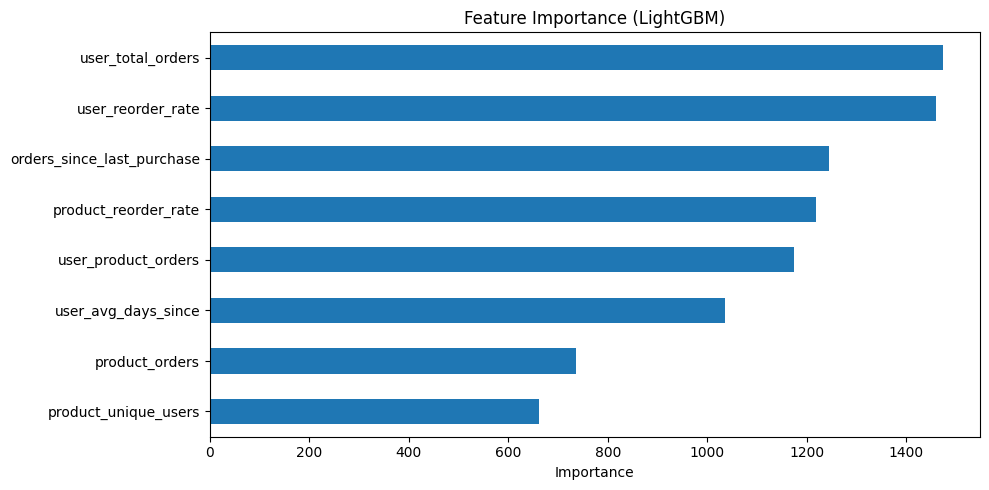

In [26]:
importance = pd.Series(lgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='barh')
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
comparison = pd.DataFrame({
    'Model':     ['Baseline', 'Logistic Regression', 'LightGBM'],
    'ROC-AUC':   ['-',
                  round(roc_auc_score(y_test, y_prob_lr), 3),
                  round(roc_auc_score(y_test, y_prob_lgb), 3)],
    'Precision': [round(precision_score(y_test, y_pred_baseline), 3),
                  round(precision_score(y_test, y_pred_lr), 3),
                  round(precision_score(y_test, y_pred_lgb), 3)],
    'Recall':    [round(recall_score(y_test, y_pred_baseline), 3),
                  round(recall_score(y_test, y_pred_lr), 3),
                  round(recall_score(y_test, y_pred_lgb), 3)],
    'F1':        [round(f1_score(y_test, y_pred_baseline), 3),
                  round(f1_score(y_test, y_pred_lr), 3),
                  round(f1_score(y_test, y_pred_lgb), 3)]
})

comparison

,Model,ROC-AUC,Precision,Recall,F1
0,Baseline,-,0.126,0.825,0.219
1,Logistic Regression,0.814,0.604,0.077,0.136
2,LightGBM,0.829,0.619,0.162,0.257


# **Сравнение моделей**

*   Baseline даёт ориентир — просто опираться на популярность товара недостаточно
*   Logistic Regression улучшает результат за счёт учёта пользовательских признаков
*   LightGBM показывает лучший ROC-AUC — нелинейные зависимости между признаками важны
*   orders_since_last_purchase и user_product_orders — наиболее важные признаки: чем чаще и недавнее покупали товар, тем выше вероятность повторного заказа

In [28]:
# Precision@K и Recall@K — метрики для recommendation-задачи
# Для каждого пользователя берём топ-K товаров по вероятности и сравниваем с реальными

def precision_at_k(df, prob_col, target_col, k=10):
    results = []
    for user_id, group in df.groupby('user_id'):
        top_k = group.nlargest(k, prob_col)[target_col]
        actual = group[target_col].sum()
        if actual == 0:
            continue
        hits = top_k.sum()
        results.append(hits / k)
    return round(sum(results) / len(results), 3)

def recall_at_k(df, prob_col, target_col, k=10):
    results = []
    for user_id, group in df.groupby('user_id'):
        top_k = group.nlargest(k, prob_col)[target_col]
        actual = group[target_col].sum()
        if actual == 0:
            continue
        hits = top_k.sum()
        results.append(hits / actual)
    return round(sum(results) / len(results), 3)

# Добавляем вероятности LightGBM к тестовой выборке
df_test = df_model.loc[X_test.index].copy()
df_test['prob_lgb'] = lgb_model.predict_proba(X_test)[:, 1]
df_test['prob_lr'] = lr.predict_proba(scaler.transform(X_test))[:, 1]
df_test['prob_baseline'] = X_test['product_reorder_rate']

for k in [5, 10]:
    print(f'--- K = {k} ---')
    print(f'Baseline   Precision@{k}:', precision_at_k(df_test, 'prob_baseline', 'reordered', k),
          f'  Recall@{k}:', recall_at_k(df_test, 'prob_baseline', 'reordered', k))
    print(f'Log Reg    Precision@{k}:', precision_at_k(df_test, 'prob_lr', 'reordered', k),
          f'  Recall@{k}:', recall_at_k(df_test, 'prob_lr', 'reordered', k))
    print(f'LightGBM   Precision@{k}:', precision_at_k(df_test, 'prob_lgb', 'reordered', k),
          f'  Recall@{k}:', recall_at_k(df_test, 'prob_lgb', 'reordered', k))
    print()

--- K = 5 ---
Baseline   Precision@5: 0.234   Recall@5: 0.632
Log Reg    Precision@5: 0.294   Recall@5: 0.756
LightGBM   Precision@5: 0.3   Recall@5: 0.769

--- K = 10 ---
Baseline   Precision@10: 0.165   Recall@10: 0.835
Log Reg    Precision@10: 0.186   Recall@10: 0.908
LightGBM   Precision@10: 0.187   Recall@10: 0.915



# **Precision@K и Recall@K**

*   Precision@K — из K показанных пользователю товаров, какая доля реально была куплена
*   Recall@K — какую долю реально купленных товаров модель смогла угадать в топ-K
*   Это правильные метрики для рекомендательной задачи: accuracy здесь бесполезен из-за сильного дисбаланса классов
*   На практике K выбирается под интерфейс продукта — например, K=10 если показываем 10 товаров на экране

In [29]:
sample_user_id = df_model['user_id'].iloc[0]

user_candidates = df_model[df_model['user_id'] == sample_user_id].copy()
user_candidates['reorder_probability'] = lgb_model.predict_proba(user_candidates[FEATURES])[:, 1]

top_recommendations = (
    user_candidates
    .merge(products[['product_id', 'product_name']], on='product_id')
    .sort_values('reorder_probability', ascending=False)
    [['product_name', 'user_product_orders', 'reorder_probability']]
    .head(10)
)

print(f'Топ-10 рекомендаций для пользователя {sample_user_id}:')
top_recommendations

Топ-10 рекомендаций для пользователя 1:


,product_name,user_product_orders,reorder_probability
3,Original Beef Jerky,10,0.792490
0,Soda,10,0.792477
1,Pistachios,9,0.734976
8,Organic String Cheese,8,0.691283
16,Zero Calorie Cola,3,0.542330
4,Cinnamon Toast Crunch,3,0.456577
13,0% Greek Strained Yogurt,1,0.365596
14,Milk Chocolate Almonds,1,0.345262
12,Organic Unsweetened Almond Milk,1,0.334857
17,Organic Half & Half,2,0.271233


# **Product Recommendations — как использовать в продукте**

*   Модель предсказывает вероятность повторного заказа для каждой пары user-product из истории
*   Топ-10 товаров с наибольшей вероятностью показываются пользователю при открытии следующего заказа
*   Порог вероятности не нужен — достаточно ранжирования по prob и показа топ-K
*   Когда показывать: при открытии нового заказа, через N дней после предыдущего (по медианному интервалу пользователя)
*   Что не покрывает модель: новые товары которые пользователь ещё не покупал — для них нужна отдельная логика (популярные в категории, collaborative filtering)

# **Итоговые выводы**

*   Около 59% товаров в заказах — повторные покупки, что делает задачу предсказания reorder хорошо решаемой
*   Пик активности пользователей — начало недели и дневные часы; интервал между заказами чаще всего 7 или 30 дней
*   Активные пользователи имеют более высокий и стабильный reorder rate — их проще моделировать
*   Ключевые признаки для модели: user_product_orders и orders_since_last_purchase — чем чаще и недавнее покупали товар, тем выше вероятность повторного заказа
*   LightGBM превосходит логистическую регрессию и baseline по ROC-AUC, F1, Precision@K и Recall@K
*   Модель применима напрямую: топ-10 товаров по вероятности — персональные рекомендации для пользователя при следующем заказе